In [12]:
# import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# lets import the dataset (here we are gonna use processed_datatcsv)
df = pd.read_csv("D:\1Rohit\Mentalhealth\Experimetation and Learning\data.csv")

In [26]:
df.dropna(inplace=True)

In [27]:
# lets do train test split
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(df["statement"],df["status"],test_size = 0.2,random_state=1,stratify=df["status"])

In [16]:
# lets a custom transformer which do feature eng and that makes raw text to clean text
import re
import string
import emoji
import nltk
import joblib

from nltk.corpus import stopwords

from sklearn.base import BaseEstimator, TransformerMixin


In [17]:
# nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

negations = {"no", "not", "nor", "n't", "never"}

stop_words = stop_words - negations

In [18]:
def preprocess_text(text):

    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = emoji.demojize(text, delimiters=(" ", " "))

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'t", " not", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [word for word in words if word not in stop_words]

    text = " ".join(words)

    return text

In [19]:
class TextFeatureExtractor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        df = pd.DataFrame()

        # original text
        df['statement'] = X

        # clean text
        df['clean_text'] = df['statement'].apply(preprocess_text)

        # numerical features
        df['statement_length'] = df['statement'].apply(len)

        df['num_words'] = df['statement'].apply(
            lambda x: len(str(x).split())
        )

        df['vocabulary_size'] = df['statement'].apply(
            lambda x: len(set(str(x).split()))
        )

        df['avg_word_length'] = np.round(
            df['statement_length'] / df['num_words'].replace(0, 1)
        )

        df['avg_word_length'] = df['avg_word_length'].astype(int)

        return df[
            [
                'clean_text',
                'statement_length',
                'num_words',
                'vocabulary_size',
                'avg_word_length'
            ]
        ]

In [ ]:
# now lets make a transformer object for doing the feature eng.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["statement_length", "num_words", "vocabulary_size", "avg_word_length"]

preprocessor = ColumnTransformer(

    transformers=[

        (
            "tfidf",
            TfidfVectorizer(
                max_features=15000,
                ngram_range=(1, 2)
            ),
            "clean_text"
        ),

        (
            "num",
            StandardScaler(),
            [
                'statement_length',
                'num_words',
                'vocabulary_size',
                'avg_word_length'
            ]
        )

    ]
)

In [ ]:
# lets import the model
import lightgbm as LGBMClassifier

In [20]:
model = LGBMClassifier(

    colsample_bytree=0.8827429375390468,

    learning_rate=0.11935107520614809,

    max_depth=5,

    min_child_samples=24,

    n_estimators=789,

    num_leaves=132,

    reg_alpha=0.6510770255019445,

    reg_lambda=0.9149596755437808,

    subsample=0.9400154311159197,

    random_state=42,

    class_weight='balanced'
)

In [22]:
# lets make a pipeline

from sklearn.pipeline import Pipeline

pipeline = Pipeline([

    ("feature_engineering", TextFeatureExtractor()),

    ("preprocessor", preprocessor),

    ("model", model)
    

])

In [28]:
pipeline.fit(xtrain,ytrain)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.361594 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 325319
[LightGBM] [Info] Number of data points in the train set: 42144, number of used features: 5581
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

Pipeline(steps=[('feature_engineering', TextFeatureExtractor()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=15000),
                                                  'clean_text'),
                                                 ('num', StandardScaler(),
                                                  ['statement_length',
                                                   'num_words',
                                                   'vocabulary_size',
                                                   'avg_word_length'])])),
                ('model',
                 LGBMClassifier(class_weight='balanced',
                                colsample_bytree=0.8827429375390468,
                                learning_rate=0.11935107520614809, max_depth=5,
                                min_child_samples=24, n_estimators=789,
                                num_leaves=132, random_state=42,
                                reg_alpha=0.6510770255019445,
                                reg_lambda=0.9149596755437808,
                                subsample=0.9400154311159197))])

                      precision    recall  f1-score   support

             Anxiety       0.79      0.83      0.81       768
             Bipolar       0.82      0.81      0.82       555
          Depression       0.75      0.67      0.71      3081
              Normal       0.91      0.93      0.92      3269
Personality disorder       0.74      0.67      0.70       216
              Stress       0.55      0.68      0.61       517
            Suicidal       0.66      0.71      0.68      2130

            accuracy                           0.78     10536
           macro avg       0.75      0.76      0.75     10536
        weighted avg       0.78      0.78      0.78     10536



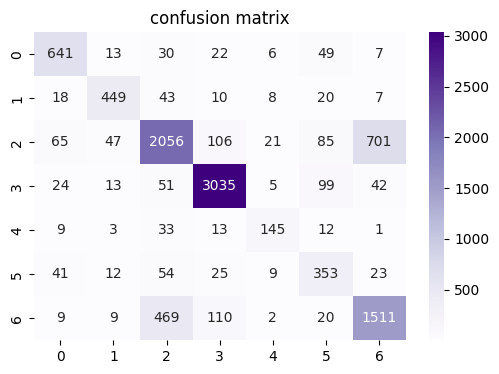

In [29]:
from sklearn.metrics import classification_report,confusion_matrix
y_pred = pipeline.predict(xtest)

print(classification_report(ytest, y_pred))

cm = confusion_matrix(ytest, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples")
plt.title("confusion matrix")
plt.show()

In [45]:
prediction = pipeline.predict(
    ["I cannot focus properly because of pressure from deadlines and responsibilities."]
)
print(prediction)

['Normal']


In [ ]:
text = "I do not see a reason to continue living anymore and I feel emotionally exhausted all the time.."

# probabilities
probs = pipeline.predict_proba([text])[0]

# class names
classes = pipeline.classes_

# predicted class index
pred_index = np.argmax(probs)

# predicted emotion
emotion = classes[pred_index]

# confidence
confidence = probs[pred_index] * 100

print(f"Prediction: {emotion}")

print(f"Confidence: {confidence:.2f}%")

print("\nAll Probabilities:\n")

for cls, prob in zip(classes, probs):

    print(f"{cls}: {prob*100:.2f}%")

Prediction: Suicidal
Confidence: 61.80%

All Probabilities:

Anxiety: 0.80%
Bipolar: 0.44%
Depression: 35.17%
Normal: 1.04%
Personality disorder: 0.55%
Stress: 0.20%
Suicidal: 61.80%


In [57]:
import joblib

joblib.dump(
    pipeline,
    "mental_health_pipeline.pkl"
)

['mental_health_pipeline.pkl']